Loaded JSON Lines format

Dataset Loaded Successfully

Columns:
Index(['content', 'annotation', 'extras'], dtype='object')

Dataset Shape: (220, 4)

TF-IDF Shape: (220, 9956)

Training Shape: (176, 9956)
Testing Shape: (44, 9956)

Model Training Completed

First 10 Predictions:
[13.36 12.   21.19 14.27 16.93 13.71 13.19 12.28 18.61 12.76]

MSE: 46.6914
RMSE: 6.8331
R2 Score: 0.1557
Tolerance Accuracy: 90.91 %

Predicted Candidate Score:
13.9


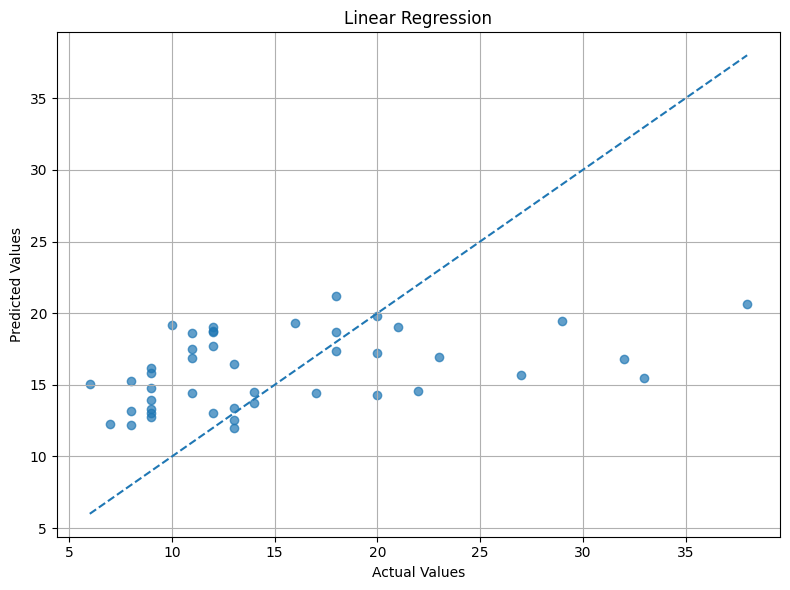

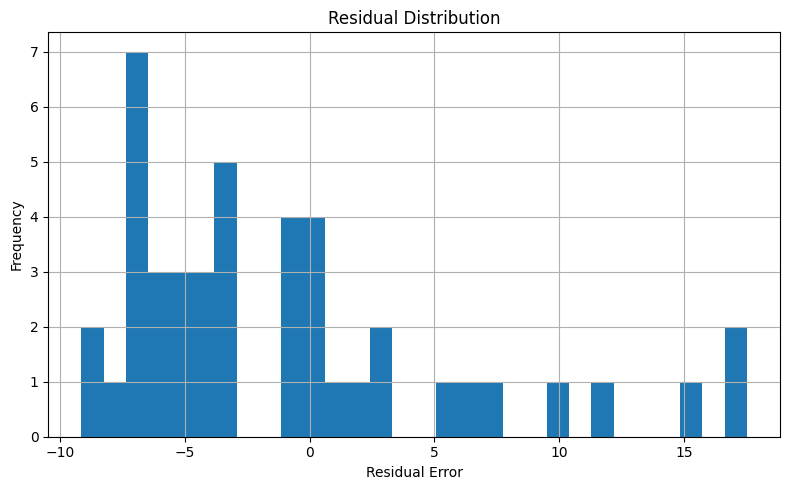


Top Features:
amazon: 17.3548
oracle: 9.5289
using: 7.7165
weblogic: 6.5869
azure: 6.4177
svn: 6.3532
physical: 6.3507
gupta: 6.261
features: 5.8778
fusion: 5.5917
configuration: 5.5359
builds: 5.5218
supplier: 5.4587
oracle fusion: 5.4456
application developer: 5.3658
end: 5.2912
velocity: 5.2175
abap: 5.0193
build: 4.9184
web: 4.904

Model Saved Successfully


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score
)

json_file = "resume_dataset.json"

try:
    data = pd.read_json(json_file, lines=True)
    print("Loaded JSON Lines format")
except:
    data = pd.read_json(json_file)
    print("Loaded Standard JSON format")

print("\nDataset Loaded Successfully")

print("\nColumns:")
print(data.columns)

text_col = "content"

data["Generated_Score"] = data["annotation"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

target_col = "Generated_Score"

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    text = re.sub(r'\s+', ' ', text)

    return text.strip()

data[text_col] = data[text_col].apply(clean_text)

data = data.dropna(subset=[text_col])

data = data[data[text_col].str.strip() != ""]

print("\nDataset Shape:", data.shape)

X = data[text_col].astype(str)

y = data[target_col].astype(float)

vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_vectorized = vectorizer.fit_transform(X)

print("\nTF-IDF Shape:", X_vectorized.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

model = Ridge(alpha=1.0)

model.fit(X_train, y_train)

print("\nModel Training Completed")

y_pred = model.predict(X_test)

print("\nFirst 10 Predictions:")
print(np.round(y_pred[:10], 2))

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\nMSE:", round(mse, 4))

print("RMSE:", round(rmse, 4))

print("R2 Score:", round(r2, 4))

tolerance = 10

correct = np.sum(
    np.abs(y_test - y_pred) <= tolerance
)

accuracy = correct / len(y_test)

print("Tolerance Accuracy:", round(accuracy * 100, 2), "%")

new_resume = """
Python Machine Learning Deep Learning
SQL NLP TensorFlow Data Science
"""

new_resume_clean = clean_text(new_resume)

new_vector = vectorizer.transform(
    [new_resume_clean]
)

prediction = model.predict(new_vector)

print("\nPredicted Candidate Score:")
print(round(float(prediction[0]), 2))

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

min_val = min(y_test.min(), y_pred.min())

max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Linear Regression")

plt.grid(True)

plt.tight_layout()

plt.savefig("linear_regression.png")

plt.show()

residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.hist(residuals, bins=30)

plt.xlabel("Residual Error")

plt.ylabel("Frequency")

plt.title("Residual Distribution")

plt.grid(True)

plt.tight_layout()

plt.savefig("residual_distribution.png")

plt.show()

feature_names = vectorizer.get_feature_names_out()

coefficients = model.coef_

top_features = sorted(
    zip(coefficients, feature_names),
    reverse=True
)[:20]

print("\nTop Features:")

for coef, feature in top_features:
    print(f"{feature}: {round(coef, 4)}")

joblib.dump(
    model,
    "linear_regression_model.pkl"
)

joblib.dump(
    vectorizer,
    "tfidf_vectorizer.pkl"
)

print("\nModel Saved Successfully")